# Importing Libraries

In [1]:
 
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.stats import poisson
from collections import defaultdict
from tqdm import tqdm

In [2]:
base_dir        = Path('../artifacts')
RAW_DATA_DIR = base_dir / 'raw_data'
MODEL_DIR       = base_dir / 'models'
METRICS_DIR     = base_dir / 'metrics'
FIGURE_DIR      = base_dir / 'figures'
SIMULATIONS_DIR = base_dir / 'simulations'
REPORTS_DIR     = base_dir / 'reports'
 
for path in [RAW_DATA_DIR,MODEL_DIR, METRICS_DIR, FIGURE_DIR, SIMULATIONS_DIR, REPORTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)
 

# Load the Data for WorldCup Schedule 

Loads two official WC 2026 files

In [3]:
gs_df = pd.read_csv(f'{RAW_DATA_DIR}/group_stages.csv', sep=';')
fk_df = pd.read_csv(f'{RAW_DATA_DIR}/fixtures_knockout_wc2026.csv')

In [4]:
df_fifa_rank = pd.read_csv(
    f'{base_dir}/raw_data/wc_2026_48_teams_fifa_rank_change.csv'
)

team_to_fifa_rank = dict(
    zip(df_fifa_rank['Nation'], df_fifa_rank['FIFA_2026_rank'])
)

In [5]:
df_features = pd.read_csv(
    f'{base_dir}/processed_data/df_features.csv',
    parse_dates=['date']
)

# WC 2026 Official Group Draw 

In [6]:
GROUPS = {}
for group_name, group_data in gs_df.groupby('group'):
    # Sort by position to preserve seeding order
    GROUPS[group_name] = (
        group_data.sort_values('position')['nation'].tolist()
    )


print(f"Groups loaded from CSV: {len(GROUPS)} groups × 4 teams")
for group_name, teams in GROUPS.items():
    print(f"  Group {group_name}: {', '.join(teams)}")

Groups loaded from CSV: 12 groups × 4 teams
  Group A: Mexico, South Africa, South Korea, Czech Republic
  Group B: Canada, Bosnia and Herzegovina, Qatar, Switzerland
  Group C: Brazil, Morocco, Haiti, Scotland
  Group D: United States, Paraguay, Australia, Turkey
  Group E: Germany, Curaçao, Ivory Coast, Ecuador
  Group F: Netherlands, Japan, Sweden, Tunisia
  Group G: Belgium, Egypt, Iran, New Zealand
  Group H: Spain, Cape Verde, Saudi Arabia, Uruguay
  Group I: France, Senegal, Iraq, Norway
  Group J: Argentina, Algeria, Austria, Jordan
  Group K: Portugal, DR Congo, Uzbekistan, Colombia
  Group L: England, Croatia, Ghana, Panama


In [7]:
HOST_NATIONS = ['United States', 'Canada', 'Mexico']

all_teams = [team for group in GROUPS.values() for team in group]

assert len(all_teams) == 48, f"Expected 48, got {len(all_teams)}"
assert len(set(all_teams)) == 48, "Duplicate teams found!"
print(f"{len(all_teams)} unique teams loaded")

48 unique teams loaded


# Loading the Models 

Loads the full model stack needed for ensemble prediction. Poisson and XGBoost are not used directly — they supply λ values to the
stacking meta-model which produces the final match probabilities.

In [11]:
poisson_home    = joblib.load(f'{MODEL_DIR}/poisson_home_final.pkl')
poisson_away    = joblib.load(f'{MODEL_DIR}/poisson_away_final.pkl')
poisson_scaler  = joblib.load(f'{MODEL_DIR}/poisson_scaler_final.pkl')

xgb_home        = joblib.load(f'{MODEL_DIR}/xgb_home_final.pkl')
xgb_away        = joblib.load(f'{MODEL_DIR}/xgb_away_final.pkl')
poisson_feature_cols = pd.read_csv(
    f'{base_dir}/features/poisson_feature_cols.csv'
).iloc[:, 0].tolist()

xgb_feature_cols = pd.read_csv(
    f'{base_dir}/features/xgb_feature_cols.csv'
).iloc[:, 0].tolist()

dc_model        = joblib.load(f'{MODEL_DIR}/dc_rho_final.pkl')
rho_fit         = dc_model['rho']

# Ensemble meta-model stays the same — evaluated on 2024 validation
meta_model      = joblib.load(f'{MODEL_DIR}/ensemble_meta_model.pkl')
scaler_meta     = joblib.load(f'{MODEL_DIR}/ensemble_meta_scaler.pkl')

print("Final models loaded (trained on 2000-2025):")
print(f"  Poisson  → poisson_home_final + poisson_away_final")
print(f"  XGBoost  → xgb_home_final + xgb_away_final")
print(f"  DC rho   → {rho_fit:.6f}")

 
# Elo ratings (latest)
df_elo_history = pd.read_csv(f'{base_dir}/processed_data/df_features.csv',
                               parse_dates=['date'])
 
print("All models loaded")

Final models loaded (trained on 2000-2025):
  Poisson  → poisson_home_final + poisson_away_final
  XGBoost  → xgb_home_final + xgb_away_final
  DC rho   → -0.123984
All models loaded


# Load Latest Elo Ratings

For each team, finds their most recent Elo rating from the historical feature dataset.

In [12]:
def get_latest_elo(df_features: pd.DataFrame) -> dict:
    """Extract most recent Elo for each team from feature dataset."""
    latest = (
        df_features.sort_values('date')
        .groupby('home_team')
        .tail(1)[['home_team', 'home_elo']]
        .rename(columns={'home_team': 'team', 'home_elo': 'elo'})
    )
    return latest.set_index('team')['elo'].to_dict()
 
elo_ratings = get_latest_elo(df_elo_history)
 
# Fill missing teams with average
avg_elo = np.mean(list(elo_ratings.values()))
missing = [t for t in all_teams if t not in elo_ratings]
if missing:
    print(f"Teams with no Elo (using avg {avg_elo:.0f}): {missing}")
    for t in missing:
        elo_ratings[t] = avg_elo
 
print(f"\nElo ratings loaded for {len(elo_ratings)} teams")
print("WC 2026 team Elo ratings:")
wc_elos = {t: round(elo_ratings.get(t, avg_elo), 1) for t in all_teams}
for group, teams in GROUPS.items():
    print(f"  Group {group}: " +
          " | ".join(f"{t} ({elo_ratings.get(t, avg_elo):.0f})" for t in teams))


Elo ratings loaded for 314 teams
WC 2026 team Elo ratings:
  Group A: Mexico (1969) | South Africa (1659) | South Korea (1876) | Czech Republic (1777)
  Group B: Canada (1898) | Bosnia and Herzegovina (1643) | Qatar (1565) | Switzerland (1946)
  Group C: Brazil (2068) | Morocco (1983) | Haiti (1714) | Scotland (1819)
  Group D: United States (1832) | Paraguay (1911) | Australia (1880) | Turkey (1954)
  Group E: Germany (1989) | Curaçao (1612) | Ivory Coast (1784) | Ecuador (2021)
  Group F: Netherlands (2000) | Japan (1979) | Sweden (1767) | Tunisia (1751)
  Group G: Belgium (1945) | Egypt (1811) | Iran (1891) | New Zealand (1767)
  Group H: Spain (2221) | Cape Verde (1655) | Saudi Arabia (1685) | Uruguay (1982)
  Group I: France (2119) | Senegal (1927) | Iraq (1744) | Norway (1961)
  Group J: Argentina (2182) | Algeria (1851) | Austria (1880) | Jordan (1777)
  Group K: Portugal (2037) | DR Congo (1771) | Uzbekistan (1824) | Colombia (2051)
  Group L: England (2082) | Croatia (1961) |

#  Pre-compute latest features for all 48 WC teams

In [13]:

# Loads each team's most recent feature values from training data


def get_latest_team_features(df: pd.DataFrame,
                              feature_cols: list,
                              perspective: str = 'home') -> dict:
    """
    perspective='home' → extracts home_* columns (home team's form)
    perspective='away' → extracts away_* columns (away team's form)
    """
    team_col = f'{perspective}_team'
    latest = (
        df.sort_values('date')
        .groupby(team_col)
        .tail(1)
        .set_index(team_col)
    )
    result = {}
    for team in latest.index:
        row   = latest.loc[team]
        feats = {}
        for col in feature_cols:
            if col in row.index:
                feats[col] = row[col]
        result[team] = feats
    return result

# Home perspective — extracts home_* columns for each team
poisson_home_feats = get_latest_team_features(
    df_features, poisson_feature_cols, perspective='home'
)
# Away perspective — extracts away_* columns for each team
poisson_away_feats = get_latest_team_features(
    df_features, poisson_feature_cols, perspective='away'
)

xgb_home_feats = get_latest_team_features(
    df_features, xgb_feature_cols, perspective='home'
)
xgb_away_feats = get_latest_team_features(
    df_features, xgb_feature_cols, perspective='away'
)

# Coverage check
covered_p = [t for t in all_teams if t in poisson_home_feats]
covered_x = [t for t in all_teams if t in xgb_home_feats]
missing_p = [t for t in all_teams if t not in poisson_home_feats]
missing_x = [t for t in all_teams if t not in xgb_home_feats]

print(f"Poisson features : {len(covered_p)}/48 teams covered")
print(f"XGBoost features : {len(covered_x)}/48 teams covered")
if missing_p: print(f"Missing Poisson  : {missing_p}")
if missing_x: print(f"Missing XGBoost  : {missing_x}")

Poisson features : 48/48 teams covered
XGBoost features : 48/48 teams covered


# DC Correction Helper 

Builds a 10×10 probability matrix for every possible scoreline (0-0 through 9-9) using DC correction applied to four low-score cells

In [14]:
MAX_GOALS = 10
goals_arr = np.arange(MAX_GOALS)   

def score_matrix_dc(lambda_h: float, lambda_a: float) -> np.ndarray:
    """Vectorised DC score matrix """
    p_home = poisson.pmf(goals_arr, lambda_h)
    p_away = poisson.pmf(goals_arr, lambda_a)
    matrix = np.outer(p_home, p_away)

    # DC low-score corrections
    matrix[0, 0] *= max(1 - lambda_h * lambda_a * rho_fit, 0)
    matrix[0, 1] *= max(1 + lambda_h * rho_fit,             0)
    matrix[1, 0] *= max(1 + lambda_a * rho_fit,             0)
    matrix[1, 1] *= max(1 - rho_fit,                        0)

    total = matrix.sum()
    return matrix / total if total > 0 else matrix
 

# Match Prediction Function

Core prediction function called for every match in the simulation.

Primary path (ensemble):
  1. Builds feature rows for Poisson and XGBoost using available tournament-time
     features: home_elo, away_elo, elo_diff, neutral, host flags
  2. Gets λ_home and λ_away from both Poisson and XGBoost
  3. Converts each λ pair to probabilities via DC score matrix
  4. Passes all 9 probabilities (3 models × 3 outcomes) to stacking meta-model
  5. Returns final prob_home_win, prob_draw, prob_away_win + score_matrix

Fallback path (DC-only):
  If KeyError or ValueError occurs (e.g. missing feature column),
  derives λ directly from Elo difference using a log-linear formula.
  Ensures every match gets a prediction even for edge cases.

Note: Features not available at tournament time (form, H2H) default to 0.
Elo, neutral venue and host flags are always set from the actual matchup.

In [15]:
def predict_match(home_team: str, away_team: str,
                  is_neutral: bool = True,
                  stage: str = 'Group Stage') -> dict:

    home_elo = elo_ratings.get(home_team, avg_elo)
    away_elo = elo_ratings.get(away_team, avg_elo)
    elo_diff = home_elo - away_elo

    try:
        #  Poisson features 
        # Start with team's latest historical features
        poisson_feats = {col: 0 for col in poisson_feature_cols}

        if home_team in poisson_home_feats:
            for col, val in poisson_home_feats[home_team].items():
                if col.startswith('home_') and col in poisson_feats:
                    poisson_feats[col] = val

        if away_team in poisson_away_feats:
            for col, val in poisson_away_feats[away_team].items():
                if col.startswith('away_') and col in poisson_feats:
                    poisson_feats[col] = val

        # Always override match-specific values
        poisson_feats['home_elo']     = home_elo
        poisson_feats['away_elo']     = away_elo
        poisson_feats['elo_diff']     = elo_diff
        poisson_feats['neutral']      = int(is_neutral)
        if 'home_is_host' in poisson_feats:
            poisson_feats['home_is_host'] = int(home_team in HOST_NATIONS)
        if 'away_is_host' in poisson_feats:
            poisson_feats['away_is_host'] = int(away_team in HOST_NATIONS)


        if 'rank_diff' in poisson_feats:
            poisson_feats['rank_diff'] = (
                team_to_fifa_rank.get(away_team, 999) -
                team_to_fifa_rank.get(home_team, 999)
            )


        X_p        = pd.DataFrame([poisson_feats])[poisson_feature_cols].fillna(0)
        X_p_scaled = poisson_scaler.transform(X_p)
        lh_p       = float(poisson_home.predict(X_p_scaled)[0])
        la_p       = float(poisson_away.predict(X_p_scaled)[0])

        sm_p   = score_matrix_dc(lh_p, la_p)
        p_hw_p = float(np.tril(sm_p, k=-1).sum())
        p_d_p  = float(np.trace(sm_p))
        p_aw_p = float(np.triu(sm_p, k=1).sum())

        #  XGBoost features 
        xgb_feats = {col: 0 for col in xgb_feature_cols}

        if home_team in xgb_home_feats:
            for col, val in xgb_home_feats[home_team].items():
                if col.startswith('home_') and col in xgb_feats:
                    xgb_feats[col] = val

        if away_team in xgb_away_feats:
            for col, val in xgb_away_feats[away_team].items():
                if col.startswith('away_') and col in xgb_feats:
                    xgb_feats[col] = val

        xgb_feats['home_elo']     = home_elo
        xgb_feats['away_elo']     = away_elo
        xgb_feats['elo_diff']     = elo_diff
        xgb_feats['neutral']      = int(is_neutral)
        if 'home_is_host' in xgb_feats:
            xgb_feats['home_is_host'] = int(home_team in HOST_NATIONS)
        if 'away_is_host' in xgb_feats:
            xgb_feats['away_is_host'] = int(away_team in HOST_NATIONS)

        if 'rank_diff' in xgb_feats:
            xgb_feats['rank_diff'] = (
                team_to_fifa_rank.get(away_team, 999) -
                team_to_fifa_rank.get(home_team, 999)
            )

        X_x  = pd.DataFrame([xgb_feats])[xgb_feature_cols].fillna(0)
        lh_x = float(xgb_home.predict(X_x)[0])
        la_x = float(xgb_away.predict(X_x)[0])

        sm_x   = score_matrix_dc(lh_x, la_x)
        p_hw_x = float(np.tril(sm_x, k=-1).sum())
        p_d_x  = float(np.trace(sm_x))
        p_aw_x = float(np.triu(sm_x, k=1).sum())

        W_POISSON = 0.60
        W_XGB     = 0.40

        prob_home_win = W_POISSON * p_hw_p + W_XGB * p_hw_x
        prob_draw     = W_POISSON * p_d_p  + W_XGB * p_d_x
        prob_away_win = W_POISSON * p_aw_p + W_XGB * p_aw_x

        # Normalise 
        total         = prob_home_win + prob_draw + prob_away_win
        prob_home_win /= total
        prob_draw     /= total
        prob_away_win /= total

        probs = [prob_home_win, prob_draw, prob_away_win]

        lambda_home = (lh_p + lh_x) / 2
        lambda_away = (la_p + la_x) / 2
        score_mat   = score_matrix_dc(lambda_home, lambda_away)

        return {
            'prob_home_win': float(probs[0]),
            'prob_draw':     float(probs[1]),
            'prob_away_win': float(probs[2]),
            'lambda_home':   round(lambda_home, 4),
            'lambda_away':   round(lambda_away, 4),
            'score_matrix':  score_mat,
            'method':        'ensemble',
        }

    except (KeyError, ValueError):
        h_adv    = 0.0 if is_neutral else 0.3
        lambda_h = np.exp(0.3 + 0.001 * elo_diff + h_adv)
        lambda_a = np.exp(0.1 - 0.001 * elo_diff)
        score_mat = score_matrix_dc(lambda_h, lambda_a)

        return {
            'prob_home_win': float(np.tril(score_mat, k=-1).sum()),
            'prob_draw':     float(np.trace(score_mat)),
            'prob_away_win': float(np.triu(score_mat, k=1).sum()),
            'lambda_home':   round(lambda_h, 4),
            'lambda_away':   round(lambda_a, 4),
            'score_matrix':  score_mat,
            'method':        'dc_fallback',
        }

In [16]:
test_matches = [
    ('Argentina', 'France'),
    ('Brazil',    'Germany'),
    ('Spain',     'England'),
    ('Argentina', 'Brazil'),
]

print("Match prediction sanity check:")
for home, away in test_matches:
    pred = predict_match(home, away, is_neutral=True, stage='Final')
    print(f"  {home:15s} vs {away:15s} → "
          f"HW:{pred['prob_home_win']:.2%}  "
          f"D:{pred['prob_draw']:.2%}  "
          f"AW:{pred['prob_away_win']:.2%}  "
          f"[{pred['method']}]")

Match prediction sanity check:
  Argentina       vs France          → HW:29.84%  D:28.49%  AW:41.67%  [ensemble]
  Brazil          vs Germany         → HW:42.95%  D:29.06%  AW:27.99%  [ensemble]
  Spain           vs England         → HW:38.76%  D:30.02%  AW:31.22%  [ensemble]
  Argentina       vs Brazil          → HW:33.86%  D:30.43%  AW:35.70%  [ensemble]


# Simulate a Single Match (stochastic) 

Samples a single scoreline from the pre-computed DC score probability matrix.

Uses np.searchsorted on the cumulative sum — ~10x faster than np.random.choice
with a probability array. Accepts a pre-sampled random number r (float 0-1)
to avoid generating randoms inside the simulation loop, which is slower.
If r is not provided, generates one on the fly (used outside Monte Carlo loop).

Returns (home_goals, away_goals) as integers via divmod on the flat matrix index.

In [17]:
def simulate_match_score(score_matrix: np.ndarray,
                          r: float = None) -> tuple:
    """Sample scoreline using fast cumsum method."""
    flat = score_matrix.ravel()
    if r is None:
        r = np.random.random()
    idx = int(np.searchsorted(np.cumsum(flat), r))
    idx = min(idx, MAX_GOALS * MAX_GOALS - 1)
    return divmod(idx, MAX_GOALS)

# Pre-compute all group stage match probabilities once

Pre-computes and caches all 72 group stage match predictions before simulations start.

Group stage matchups are fixed (same 48 teams, same groups every simulation) so
predict_match() would return identical results if called 100,000 times per match.
By caching all 72 predictions upfront, each simulation retrieves predictions via
dict lookup (O(1)) instead of running Poisson + XGBoost + ensemble (O(n)).

Speed impact: eliminates 72 × 100,000 = 7.2 million redundant model calls.

In [18]:
print("Pre-computing group stage match probabilities...")
group_match_cache = {}

for group_name, teams in GROUPS.items():
    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            home, away = teams[i], teams[j]
            pred = predict_match(home, away, is_neutral=True,
                                 stage='Group Stage')
            group_match_cache[(home, away)] = pred

print(f"Cached {len(group_match_cache)} group stage matchups")
print("Expected: 72 matchups (12 groups × 6 matches each)")

Pre-computing group stage match probabilities...
Cached 72 group stage matchups
Expected: 72 matchups (12 groups × 6 matches each)


# Global knockout prediction cache


Same caching principle as the group stage cache but for knockout rounds.
Knockout matchups are not fixed (teams depend on group results) but many
matchup combinations repeat across 100,000 simulations — e.g. Brazil vs Argentina
may appear in the QF in thousands of simulations.

Uses a dict keyed by (home_team, away_team, stage). First time a matchup is seen,
predict_match() is called and result stored. Subsequent simulations with the same
matchup use the cached result directly.

In [19]:
knockout_cache = {}

def predict_match_cached(home_team: str, away_team: str,
                          is_neutral: bool = True,
                          stage: str = 'Group Stage') -> dict:
    key = (home_team, away_team, stage)
    if key not in knockout_cache:
        knockout_cache[key] = predict_match(
            home_team, away_team, is_neutral=is_neutral, stage=stage
        )
    return knockout_cache[key]

# Group Stage Points 

Standard football points system:
  Win  → 3 points for winner, 0 for loser
  Draw → 1 point each
  Loss → 0 points for loser, 3 for winner

Returns (home_points, away_points) tuple used to update standings after each
simulated group stage match.

In [20]:
def group_stage_points(goals_for, goals_against):
    if goals_for > goals_against:  return 3, 0
    if goals_for == goals_against: return 1, 1
    return 0, 3

# WC 2026 Format 

simulate_group_stage():
  Simulates all 72 group stage matches using pre-sampled random numbers.
  For each group, runs round-robin (6 matches per group × 12 groups = 72 total).
  Each match samples a scoreline from the cached score matrix using one
  pre-sampled random number — no model calls, no random generation inside loop.
  Sorts final standings by points → goal difference → goals scored.

simulate_tournament():
  Orchestrates the full WC 2026 from group stage through to the Final.

  Two modes:
    deterministic=True  → uses round(λ) for scores, argmax for knockout winners
                          Produces the single "most likely" tournament bracket
    deterministic=False → samples scorelines from score matrices using randoms
                          Each run produces a different outcome

  Group stage:
    Calls simulate_group_stage() for stochastic mode.
    Runs deterministic group stage inline for deterministic mode.

  3rd place qualification:
    Collects the 3rd-place team from each group, ranks by points/GD/GF,
    takes the top 8 — matching the official WC 2026 format.

  resolve_slot():
    Decodes bracket slot codes from fixtures CSV into actual team names:
      '1A'      → 1st place Group A
      '2B'      → 2nd place Group B
      '3ABCDF'  → best 3rd-place team from groups A/B/C/D/F
      'W73'     → winner of match M73
      'RU_M73'  → loser of match M73 (for 3rd-place match)

  Knockout rounds:
    Iterates R32 → R16 → QF → SF → 3rd → Final following fk_df fixture order.
    For draws (equal goals), resolves via penalty probability using a
    pre-sampled random number — no extra model calls needed.
    Tracks both winner and loser of each match for bracket resolution.

In [21]:
def simulate_group_stage(randoms: np.ndarray) -> dict:
    """
    Simulate all 72 group matches using pre-sampled randoms.
    randoms: 1D array of at least 72 uniform(0,1) values
    """
    group_standings = {}
    rand_ptr = [0]

    for group_name, teams in GROUPS.items():
        stats = {t: {'team': t, 'group': group_name,
                     'points': 0, 'gf': 0, 'ga': 0, 'gd': 0}
                 for t in teams}

        for i in range(len(teams)):
            for j in range(i + 1, len(teams)):
                home, away = teams[i], teams[j]
                pred  = group_match_cache[(home, away)]
                r     = randoms[rand_ptr[0]]
                rand_ptr[0] += 1
                hg, ag = simulate_match_score(pred['score_matrix'], r)

                hp, ap = group_stage_points(hg, ag)
                for team, gf, ga, pts in [(home, hg, ag, hp),
                                           (away, ag, hg, ap)]:
                    stats[team]['points'] += pts
                    stats[team]['gf']     += gf
                    stats[team]['ga']     += ga
                    stats[team]['gd']      = (stats[team]['gf'] -
                                              stats[team]['ga'])

        # Sort: points → GD → GF → FIFA rank (lower = better, tiebreaker)
        group_standings[group_name] = sorted(
            stats.values(),
            key=lambda x: (
                x['points'],
                x['gd'],
                x['gf'],
                -team_to_fifa_rank.get(x['team'], 999)   # ← improvement 1
            ),
            reverse=True
        )

    return group_standings


def simulate_tournament(deterministic: bool = False,
                         randoms: np.ndarray = None) -> dict:
    """
    Simulate full WC 2026 using official bracket from fixtures CSV.

    deterministic=True  → win probability argmax for group stage + knockout
    deterministic=False → sample scorelines from score matrices using randoms
    randoms             → 1D array of 150 uniform(0,1) values

    Tiebreaker order: points → GD → GF → FIFA rank (lower = better)

    3rd-place slot assignment uses constraint-based matching:
    Groups K and L have only ONE eligible slot each (M80 and M87).
    Processed first to guarantee they are never blocked.
    """

    # ── Group Stage ───────────────────────────────────────────
    if randoms is None:
        randoms = np.random.random(150)

    rand_ptr = [0]

    if deterministic:
        group_standings = {}
        for group_name, teams in GROUPS.items():
            stats = {t: {'team': t, 'group': group_name,
                         'points': 0, 'gf': 0, 'ga': 0, 'gd': 0}
                     for t in teams}
            for i in range(len(teams)):
                for j in range(i + 1, len(teams)):
                    home, away = teams[i], teams[j]
                    pred = group_match_cache[(home, away)]

                    p_hw = pred['prob_home_win']
                    p_d  = pred['prob_draw']
                    p_aw = pred['prob_away_win']

                    if p_hw >= p_d and p_hw >= p_aw:
                        hg, ag = 1, 0
                    elif p_aw >= p_d and p_aw >= p_hw:
                        hg, ag = 0, 1
                    else:
                        hg, ag = 1, 1

                    hp, ap = group_stage_points(hg, ag)
                    for team, gf, ga, pts in [(home, hg, ag, hp),
                                               (away, ag, hg, ap)]:
                        stats[team]['points'] += pts
                        stats[team]['gf']     += gf
                        stats[team]['ga']     += ga
                        stats[team]['gd']      = (stats[team]['gf'] -
                                                  stats[team]['ga'])

            # Sort: points → GD → GF → FIFA rank (tiebreaker)
            group_standings[group_name] = sorted(
                stats.values(),
                key=lambda x: (
                    x['points'],
                    x['gd'],
                    x['gf'],
                    -team_to_fifa_rank.get(x['team'], 999)  
                ),
                reverse=True
            )
    else:
        group_standings = simulate_group_stage(randoms)
        rand_ptr[0] = 72

    #  Best 3rd-place teams (top 8 of 12 advance)
    third_place = []
    for group_name, standings in group_standings.items():
        third = standings[2].copy()
        third['group'] = group_name
        third_place.append(third)


    best_thirds = sorted(
        third_place,
        key=lambda x: (
            x['points'],
            x['gd'],
            x['gf'],
            -team_to_fifa_rank.get(x['team'], 999)   
        ),
        reverse=True
    )[:8]

    advancing_groups = {t['group'] for t in best_thirds}

    #  Constraint-based 3rd-place slot assignment 
    THIRD_PLACE_SLOTS = {
        'M74': set('ABCDF'),
        'M77': set('CDFGH'),
        'M79': set('CEFHI'),
        'M80': set('EHIJK'),
        'M81': set('BEFIJ'),
        'M82': set('AEHIJ'),
        'M85': set('EFGIJ'),
        'M87': set('DEIJL'),
    }

    group_to_team     = {t['group']: t['team'] for t in best_thirds}
    remaining_groups  = set(advancing_groups)
    third_slot_assignments = {}
    unassigned_slots  = dict(THIRD_PLACE_SLOTS)

    while unassigned_slots and remaining_groups:
        best_slot = min(
            unassigned_slots.keys(),
            key=lambda m: len(unassigned_slots[m] & remaining_groups)
        )
        eligible_advancing = unassigned_slots[best_slot] & remaining_groups

        if eligible_advancing:
            chosen_group = min(
                eligible_advancing,
                key=lambda g: next(
                    i for i, t in enumerate(best_thirds) if t['group'] == g
                )
            )
            third_slot_assignments[best_slot] = group_to_team[chosen_group]
            remaining_groups.discard(chosen_group)
        else:
            if remaining_groups:
                fallback_group = min(
                    remaining_groups,
                    key=lambda g: next(
                        i for i, t in enumerate(best_thirds) if t['group'] == g
                    )
                )
                third_slot_assignments[best_slot] = group_to_team[fallback_group]
                remaining_groups.discard(fallback_group)

        del unassigned_slots[best_slot]

    #  Slot Resolver 
    def resolve_slot(slot: str, match_winners: dict,
                     current_match_id: str = None) -> str | None:
        if slot.startswith('W'):
            return match_winners.get('M' + slot[1:])
        if slot.startswith('RU'):
            return match_winners.get('RU_M' + slot[2:])
        if slot[0].isdigit() and len(slot) >= 2:
            pos, group = int(slot[0]), slot[1]
            if pos <= 2:
                return group_standings[group][pos - 1]['team']
        if slot.startswith('3'):
            team = third_slot_assignments.get(current_match_id)
            if team is None:
                print(f"WARNING: No assignment for "
                      f"{current_match_id} (slot={slot})")
            return team
        return None

    #  Knockout Rounds 
    match_winners = {}
    round_results = {'group_stage': group_standings}
    round_order   = ['R32', 'R16', 'QF', 'SF', '3rd', 'Final']

    for round_name in round_order:
        round_matches  = fk_df[fk_df['round'] == round_name].copy()
        round_matchups = []
        round_winners  = []

        for _, fixture in round_matches.iterrows():
            match_id  = fixture['match_id']
            home_slot = fixture['home_slot']
            away_slot = fixture['away_slot']

            home = resolve_slot(home_slot, match_winners,
                                current_match_id=match_id)
            away = resolve_slot(away_slot, match_winners,
                                current_match_id=match_id)

            if home is None or away is None:
                print(f"WARNING: {match_id} unresolved — "
                      f"home={home_slot}→{home}  "
                      f"away={away_slot}→{away}")
                continue

            pred = predict_match_cached(home, away,
                                         is_neutral=True,
                                         stage=round_name)

            if deterministic:
                winner = (home if pred['prob_home_win'] >= pred['prob_away_win']
                          else away)
                loser  = (away if pred['prob_home_win'] >= pred['prob_away_win']
                          else home)
            else:
                r      = randoms[rand_ptr[0]]
                rand_ptr[0] += 1
                hg, ag = simulate_match_score(pred['score_matrix'], r)

                if hg > ag:
                    winner, loser = home, away
                elif ag > hg:
                    winner, loser = away, home
                else:
                    r_pen  = randoms[rand_ptr[0]]
                    rand_ptr[0] += 1
                    p_home = pred['prob_home_win'] / (
                        pred['prob_home_win'] + pred['prob_away_win']
                    )
                    winner, loser = ((home, away) if r_pen < p_home
                                     else (away, home))

            match_winners[match_id]         = winner
            match_winners[f'RU_{match_id}'] = loser
            round_matchups.append((home, away))
            round_winners.append(winner)

        round_results[round_name] = {
            'matchups': round_matchups,
            'winners':  round_winners,
        }

    round_results['champion'] = match_winners.get('M104')
    return round_results

# Deterministic Simulation

Runs one full tournament using expected values throughout:
  - Group stage: round(λ_home) vs round(λ_away) for each match
  - Knockout: team with higher win probability advances

Produces the single "most likely" bracket — the tournament outcome the model
considers most probable given current team strengths. Printed round by round
from R32 through to the Final and champion.

This is the fast sanity check before running 100,000 stochastic simulations.

In [22]:

def check_bracket(result: dict) -> bool:
    """Verify bracket resolved correctly — all 32 teams present, no duplicates."""
    if 'R32' not in result:
        print("❌ R32 missing from result")
        return False

    r32_teams = [t for matchup in result['R32']['matchups'] for t in matchup]

    if len(r32_teams) != 32:
        print(f"❌ Expected 32 R32 teams, got {len(r32_teams)}")
        return False

    if len(set(r32_teams)) != 32:
        dupes = [t for t in r32_teams if r32_teams.count(t) > 1]
        print(f"❌ Duplicate teams in R32: {set(dupes)}")
        return False

    if result['champion'] is None:
        print("❌ Champion is None — Final did not resolve")
        return False

    print(f" Bracket verified: 32 unique teams in R32")
    print(f" Champion resolved: {result['champion']}")
    return True



print("Running deterministic simulation...")
det_result = simulate_tournament(deterministic=True)

print(f"\n Deterministic Result ")
print(f"Champion: {det_result['champion']} 🏆")

# Run sanity check
bracket_ok = check_bracket(det_result)

if bracket_ok:
    print(f"\nQualified for Round of 32:")
    r32_teams = [t for matchup in det_result['R32']['matchups']
                 for t in matchup]
    for i, team in enumerate(r32_teams, 1):
        print(f"  {i:2d}. {team}")

    round_display = {
        'R32':   'Round of 32',
        'R16':   'Round of 16',
        'QF':    'Quarter-finals',
        'SF':    'Semi-finals',
        '3rd':   'Third-place match',
        'Final': 'Final',
    }

    for round_code, round_label in round_display.items():
        if round_code not in det_result:
            continue
        rd = det_result[round_code]
        print(f"\n {round_label} ")
        for (h, a), w in zip(rd['matchups'], rd['winners']):
            print(f"  {h:25s} vs {a:25s}  → {w}")
else:
    print("\n Fix bracket issues before running Monte Carlo")

Running deterministic simulation...

 Deterministic Result 
Champion: Argentina 🏆
 Bracket verified: 32 unique teams in R32
 Champion resolved: Argentina

Qualified for Round of 32:
   1. South Korea
   2. Canada
   3. Germany
   4. Paraguay
   5. Netherlands
   6. Morocco
   7. Brazil
   8. Japan
   9. France
  10. Egypt
  11. Ecuador
  12. Senegal
  13. Mexico
  14. Norway
  15. England
  16. Algeria
  17. United States
  18. Ivory Coast
  19. Belgium
  20. Czech Republic
  21. Colombia
  22. Croatia
  23. Spain
  24. Austria
  25. Switzerland
  26. Sweden
  27. Argentina
  28. Uruguay
  29. Portugal
  30. Panama
  31. Turkey
  32. Iran

 Round of 32 
  South Korea               vs Canada                     → South Korea
  Germany                   vs Paraguay                   → Germany
  Netherlands               vs Morocco                    → Netherlands
  Brazil                    vs Japan                      → Brazil
  France                    vs Egypt                      →

# Monte Carlo Simulation 

Runs 100,000 full tournament simulations to build probability distributions.

Performance optimisations applied:
  1. Pre-sampled randoms: np.random.random((100000, 150)) generates all random
     numbers upfront in one NumPy call — much faster than per-match generation
  2. Group cache: no model calls during group stage — pure dict lookups
  3. Knockout cache: repeated matchups reuse cached predictions
  4. Fast score sampling: np.searchsorted on cumsum instead of np.random.choice

Seven counters track how often each team reaches each stage across all simulations:
  champion_count, finalist_count, semifinal_count, quarterfinal_count,
  r16_count, r32_count, group_wins_count

tqdm progress bar shows estimated time remaining during the run.

In [23]:
N_SIMULATIONS    = 100_000
RANDOMS_PER_SIM  = 150   # 72 group + ~60 knockout + buffer

# Pre-sample all randoms at once — much faster than per-match
all_randoms = np.random.random((N_SIMULATIONS, RANDOMS_PER_SIM))

champion_count     = defaultdict(int)
finalist_count     = defaultdict(int)
semifinal_count    = defaultdict(int)
quarterfinal_count = defaultdict(int)
r16_count          = defaultdict(int)
r32_count          = defaultdict(int)
group_wins_count   = defaultdict(int)

print(f"Running {N_SIMULATIONS:,} Monte Carlo simulations...")

for sim in tqdm(range(N_SIMULATIONS), desc='Simulating'):
    result = simulate_tournament(
        deterministic=False,
        randoms=all_randoms[sim]   # ← pass pre-sampled randoms
    )

    champion_count[result['champion']] += 1

    if 'Final' in result and result['Final']['matchups']:
        for t in result['Final']['matchups'][0]:
            finalist_count[t] += 1

    if 'SF' in result:
        for matchup in result['SF']['matchups']:
            for t in matchup:
                semifinal_count[t] += 1

    if 'QF' in result:
        for matchup in result['QF']['matchups']:
            for t in matchup:
                quarterfinal_count[t] += 1

    if 'R16' in result:
        for matchup in result['R16']['matchups']:
            for t in matchup:
                r16_count[t] += 1

    if 'R32' in result:
        for matchup in result['R32']['matchups']:
            for t in matchup:
                r32_count[t] += 1

    for group_name, standings in result['group_stage'].items():
        group_wins_count[standings[0]['team']] += 1

Running 100,000 Monte Carlo simulations...


Simulating: 100%|██████████| 100000/100000 [52:39<00:00, 31.65it/s]  


# Build Results DataFrame 

Converts raw simulation counts into percentage probabilities for all 48 teams
across 7 tournament milestones:
  group_win_pct   : probability of finishing 1st in group
  qualify_r32_pct : probability of reaching Round of 32 (top 2 + best 3rd)
  reach_r16_pct   : probability of reaching Round of 16
  reach_qf_pct    : probability of reaching Quarter-finals
  reach_sf_pct    : probability of reaching Semi-finals
  reach_final_pct : probability of reaching the Final
  win_pct         : probability of winning the tournament

Sorted by win_pct descending — highest-probability champion at top.
With 100,000 simulations, probabilities are accurate to ±0.3% at 95% confidence.

In [24]:
mc_results = pd.DataFrame({'team': all_teams})
 
mc_results['group_win_pct']    = mc_results['team'].map(
    lambda t: group_wins_count.get(t, 0) / N_SIMULATIONS * 100)
mc_results['qualify_r32_pct']  = mc_results['team'].map(
    lambda t: r32_count.get(t, 0) / N_SIMULATIONS * 100)
mc_results['reach_r16_pct']    = mc_results['team'].map(
    lambda t: r16_count.get(t, 0) / N_SIMULATIONS * 100)
mc_results['reach_qf_pct']     = mc_results['team'].map(
    lambda t: quarterfinal_count.get(t, 0) / N_SIMULATIONS * 100)
mc_results['reach_sf_pct']     = mc_results['team'].map(
    lambda t: semifinal_count.get(t, 0) / N_SIMULATIONS * 100)
mc_results['reach_final_pct']  = mc_results['team'].map(
    lambda t: finalist_count.get(t, 0) / N_SIMULATIONS * 100)
mc_results['win_pct']          = mc_results['team'].map(
    lambda t: champion_count.get(t, 0) / N_SIMULATIONS * 100)
 
mc_results = mc_results.sort_values('win_pct', ascending=False).reset_index(drop=True)

print("\n Top 20 Teams  Win Probability ")
print(mc_results.head(20)[[
    'team', 'win_pct', 'reach_final_pct', 'reach_sf_pct',
    'reach_qf_pct', 'reach_r16_pct', 'qualify_r32_pct'
]].to_string(index=False))


 Top 20 Teams  Win Probability 
       team  win_pct  reach_final_pct  reach_sf_pct  reach_qf_pct  reach_r16_pct  qualify_r32_pct
      Spain   10.371           16.854        26.125        38.685         59.446           92.125
    England    9.708           16.173        25.373        39.773         60.328           91.387
     France    9.490           15.896        26.622        40.847         61.948           88.549
     Brazil    8.788           15.165        25.381        41.049         61.546           92.889
  Argentina    7.127           12.134        19.162        31.307         49.460           80.557
   Colombia    5.551           10.279        18.956        31.839         52.190           80.592
   Portugal    5.129            9.752        18.647        32.509         55.450           85.473
Netherlands    3.423            7.147        13.502        26.296         44.919           82.127
    Ecuador    3.088            6.687        11.930        20.817         42.519     

# Visualisations 

## Win Probability — Top 20 Teams

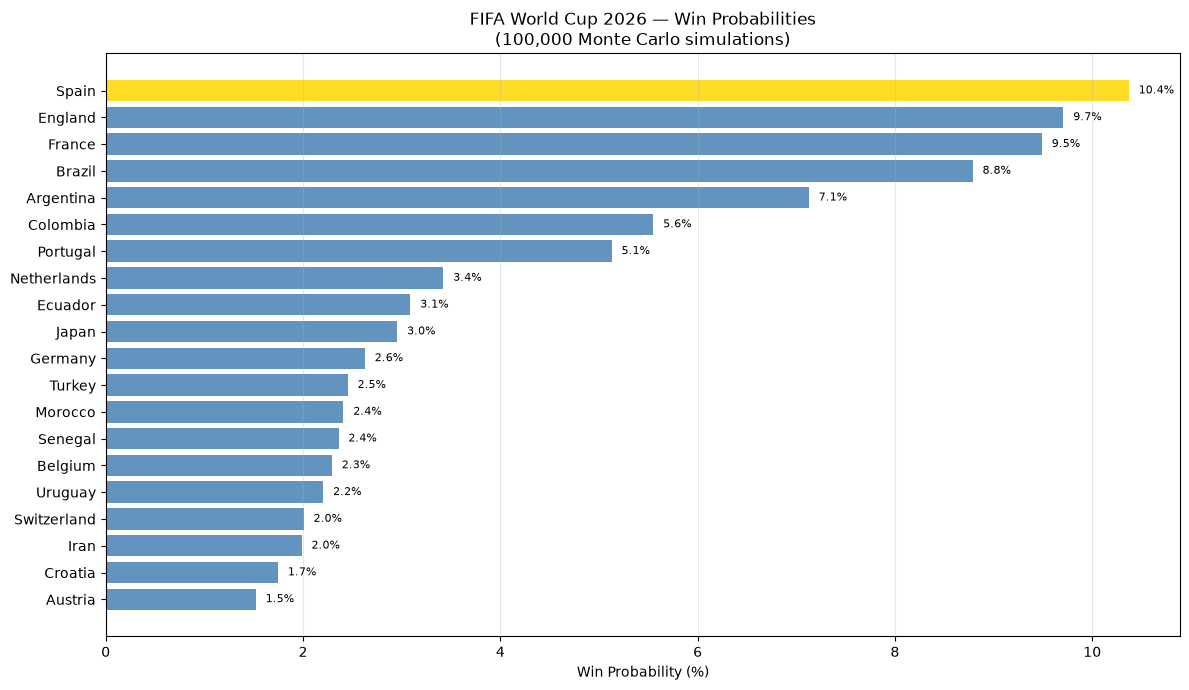

In [25]:
top20 = mc_results.head(20)
 
fig, ax = plt.subplots(figsize=(12, 7))
colors  = ['gold' if i == 0 else 'steelblue' for i in range(len(top20))]
bars    = ax.barh(top20['team'][::-1], top20['win_pct'][::-1],
                  color=colors[::-1], alpha=0.85)
 
for bar, val in zip(bars, top20['win_pct'][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
 
ax.set_xlabel('Win Probability (%)')
ax.set_title(f'FIFA World Cup 2026 — Win Probabilities\n'
             f'({N_SIMULATIONS:,} Monte Carlo simulations)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/wc2026_win_probabilities.png', dpi=150)
plt.show()

## Tournament Progression Heatmap

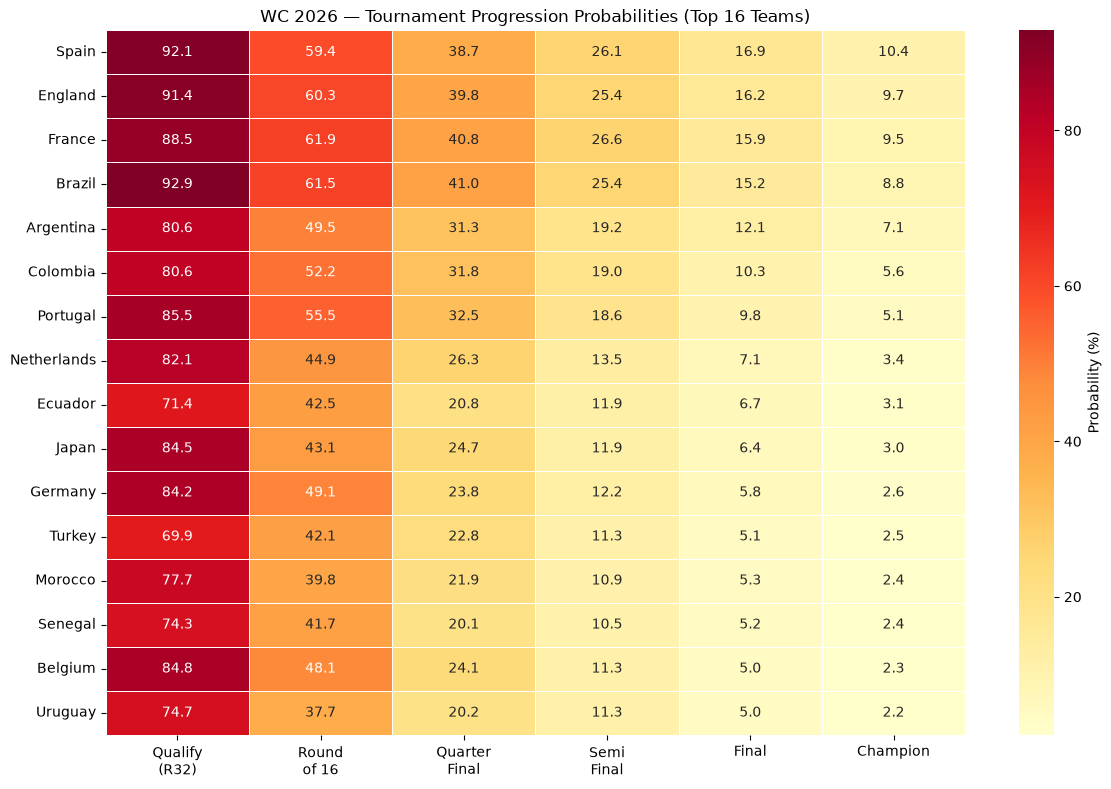

In [26]:
top16     = mc_results.head(16)
prog_cols = ['qualify_r32_pct', 'reach_r16_pct', 'reach_qf_pct',
             'reach_sf_pct', 'reach_final_pct', 'win_pct']
prog_labels = ['Qualify\n(R32)', 'Round\nof 16', 'Quarter\nFinal',
               'Semi\nFinal', 'Final', 'Champion']
 
prog_data = top16.set_index('team')[prog_cols]
 
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    prog_data, annot=True, fmt='.1f', cmap='YlOrRd',
    xticklabels=prog_labels, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Probability (%)'}
)
ax.set_title('WC 2026 — Tournament Progression Probabilities (Top 16 Teams)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/wc2026_progression_heatmap.png', dpi=150)
plt.show()
 

## Group-by-Group Win Probabilities

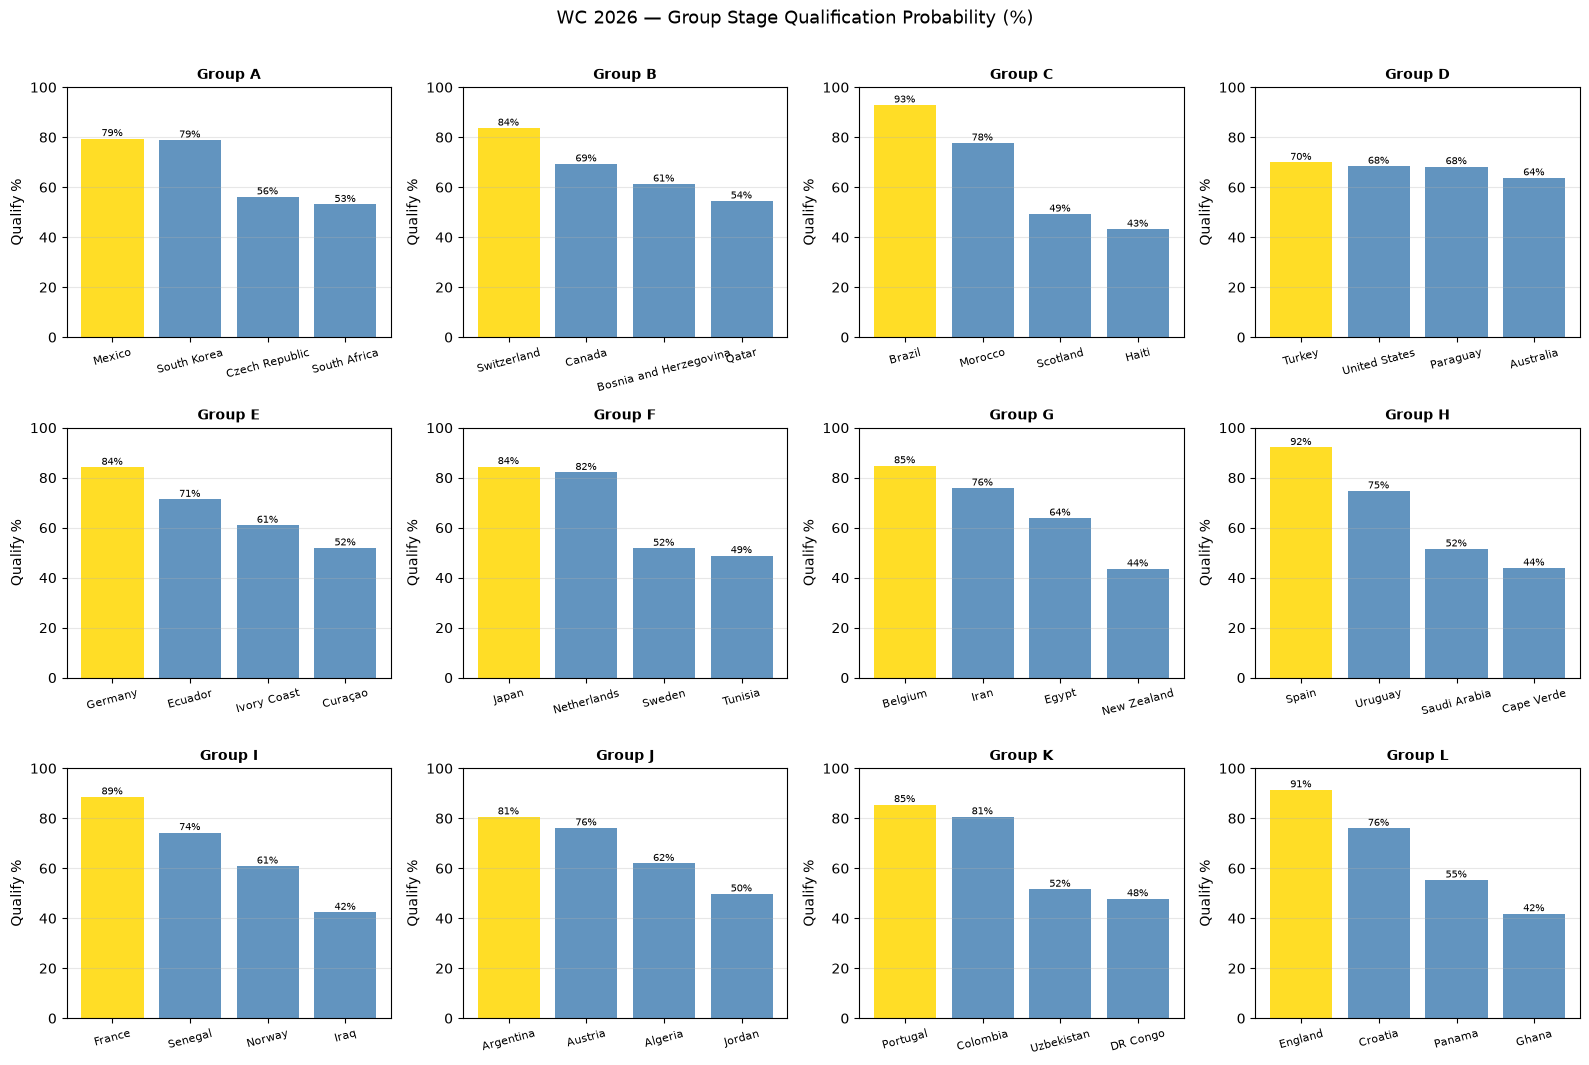

In [27]:
n_groups = len(GROUPS)
n_cols   = 4
n_rows   = (n_groups + n_cols - 1) // n_cols
 
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes_flat = axes.flatten()
 
for idx, (group_name, teams) in enumerate(GROUPS.items()):
    ax    = axes_flat[idx]
    g_data = mc_results[mc_results['team'].isin(teams)].copy()
    g_data = g_data.sort_values('qualify_r32_pct', ascending=False)
 
    colors_g = ['gold' if i == 0 else 'steelblue' for i in range(len(g_data))]
    ax.bar(g_data['team'], g_data['qualify_r32_pct'],
           color=colors_g, alpha=0.85)
    ax.set_title(f'Group {group_name}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Qualify %')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
 
    for i, (_, row) in enumerate(g_data.iterrows()):
        ax.text(i, row['qualify_r32_pct'] + 1,
                f"{row['qualify_r32_pct']:.0f}%",
                ha='center', fontsize=7)

for idx in range(len(GROUPS), len(axes_flat)):
    axes_flat[idx].set_visible(False)
 
plt.suptitle('WC 2026 — Group Stage Qualification Probability (%)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/wc2026_group_probabilities.png', dpi=150, bbox_inches='tight')
plt.show()
 


## Champion Probability Distribution

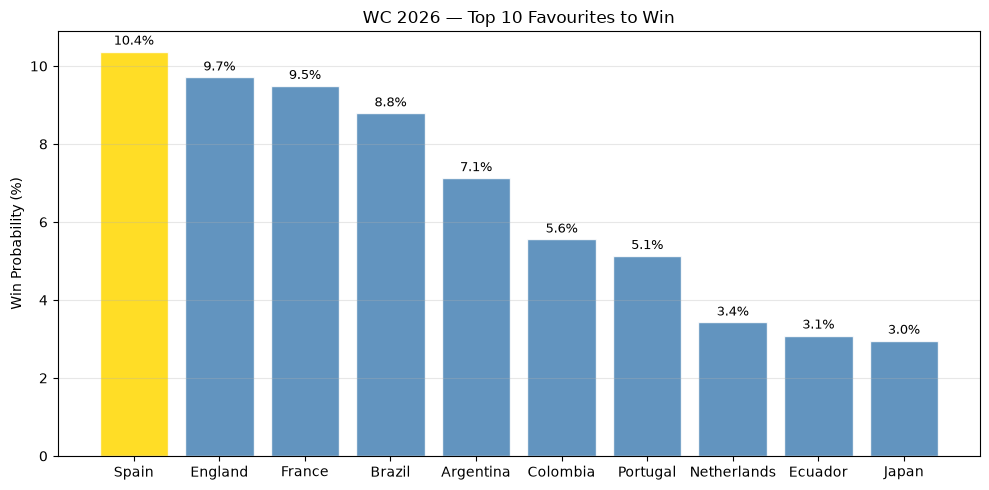

In [28]:
top10 = mc_results.head(10)
 
fig, ax = plt.subplots(figsize=(10, 5))
colors_c = ['gold'] + ['steelblue'] * 9
 
ax.bar(top10['team'], top10['win_pct'], color=colors_c, alpha=0.85, edgecolor='white')
ax.set_ylabel('Win Probability (%)')
ax.set_title('WC 2026 — Top 10 Favourites to Win', fontsize=12)
for i, (_, row) in enumerate(top10.iterrows()):
    ax.text(i, row['win_pct'] + 0.1, f"{row['win_pct']:.1f}%",
            ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/wc2026_top10_favourites.png', dpi=150)
plt.show()

## Confidence Intervals

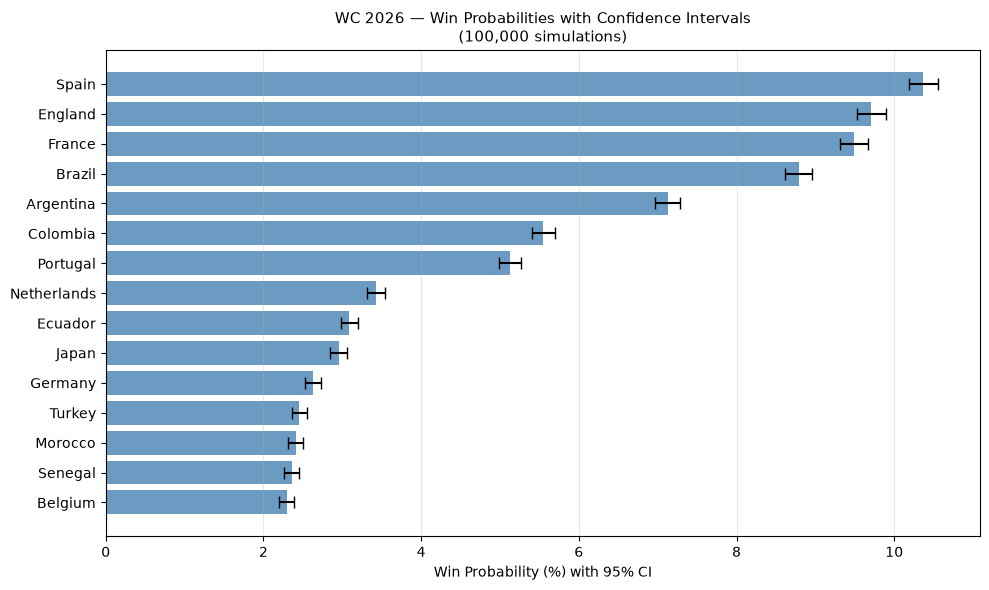

In [29]:
top15 = mc_results.head(15).copy()
top15['p']     = top15['win_pct'] / 100
top15['ci_95'] = 1.96 * np.sqrt(top15['p'] * (1 - top15['p']) / N_SIMULATIONS) * 100
 
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['team'][::-1], top15['win_pct'][::-1],
        xerr=top15['ci_95'][::-1],
        color='steelblue', alpha=0.8, capsize=4, ecolor='black')
 
ax.set_xlabel('Win Probability (%) with 95% CI')
ax.set_title(f'WC 2026 — Win Probabilities with Confidence Intervals\n'
             f'({N_SIMULATIONS:,} simulations)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/wc2026_confidence_intervals.png', dpi=150)
plt.show()

# Save Results

In [30]:
# Full MC results table
mc_results.to_csv(f'{SIMULATIONS_DIR}/wc2026_mc_results.csv', index=False)
 
# Deterministic bracket
det_bracket = {
    'champion':       det_result['champion'],
    'finalists':      list(det_result['Final']['matchups'][0])
                      if det_result.get('Final', {}).get('matchups') else [],
    'semi_finals':    [list(m) for m in det_result.get('SF',  {}).get('matchups', [])],
    'quarter_finals': [list(m) for m in det_result.get('QF',  {}).get('matchups', [])],
    'r16':            [list(m) for m in det_result.get('R16', {}).get('matchups', [])],
    'r32':            [list(m) for m in det_result.get('R32', {}).get('matchups', [])],
}
with open(f'{SIMULATIONS_DIR}/wc2026_deterministic.json', 'w') as f:
    json.dump(det_bracket, f, indent=2)
 
# Summary config
sim_config = {
    'n_simulations':    N_SIMULATIONS,
    'host_nations':     HOST_NATIONS,
    'deterministic_champion': det_result['champion'],
    'mc_top5': mc_results.head(5)[['team', 'win_pct']].to_dict('records'),
}
with open(f'{SIMULATIONS_DIR}/wc2026_config.json', 'w') as f:
    json.dump(sim_config, f, indent=2)
 
print("\nSaved:")
print(f"  simulations/ → wc2026_mc_results.csv")
print(f"  simulations/ → wc2026_deterministic.json")
print(f"  simulations/ → wc2026_config.json")
print(f"  figures/     → wc2026_*.png  (5 plots)")
print(f"\n{'='*60}")
print(f"DETERMINISTIC CHAMPION : {det_result['champion']} 🏆")
print(f"MC TOP 5 FAVOURITES:")
for _, row in mc_results.head(5).iterrows():
    print(f"  {row['team']:25s} {row['win_pct']:.2f}%")
print(f"{'='*60}")


Saved:
  simulations/ → wc2026_mc_results.csv
  simulations/ → wc2026_deterministic.json
  simulations/ → wc2026_config.json
  figures/     → wc2026_*.png  (5 plots)

DETERMINISTIC CHAMPION : Argentina 🏆
MC TOP 5 FAVOURITES:
  Spain                     10.37%
  England                   9.71%
  France                    9.49%
  Brazil                    8.79%
  Argentina                 7.13%
